# Actividad: Regresión lineal simple con el conjunto de datos Iris

Fecha: 2026-07

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# Regresión lineal simple con el conjunto de datos Iris

## Objetivo

En esta actividad se utilizará el conjunto de datos **Iris** para estimar un modelo de regresión lineal para modelar el largo del pétalo en base al largo del sépalo de la variedad Virginica.

Para esta actividad deberá:

- Estimar el modelo de regresión lineal simple.
- Proporción la ecuación de la recta estimada.
- Realizar la prueba de signficancia para la pendiente (utilice un nivel de signficancia del 5%).
- Interpretar el coeficiente estimado de la pendiente.
- Realizar e interpretar un intervalo de confianza para la pendiente.
- Realizar e interpretar un intervalo de confianza para el largo del pétalo esperado de virginicas con sépalos de 6 cm de largo.  
- Realizar e interpretar un intervalo de confianza para el largo del pétalo de cada virginica con sépalo de 6 cm de largo.  
- Redactar un resumen del análisis en el contexto del problema.

# Paso 1. Lectura del conjunto de datos

In [32]:
iris = pd.read_csv("iris_dataset.csv")

display(iris.head())

display(iris.info())

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


None

# Paso 2. Preparación del conjunto de datos para el análisis

In [33]:
#set de datos de virginicas

virginica = iris[iris["variety"] == "virginica"].copy()
virginica = virginica.rename(columns={'sepal.length': 'sepal_length', 'petal.length': 'petal_length'})

# explorar relación lineal gráficamente

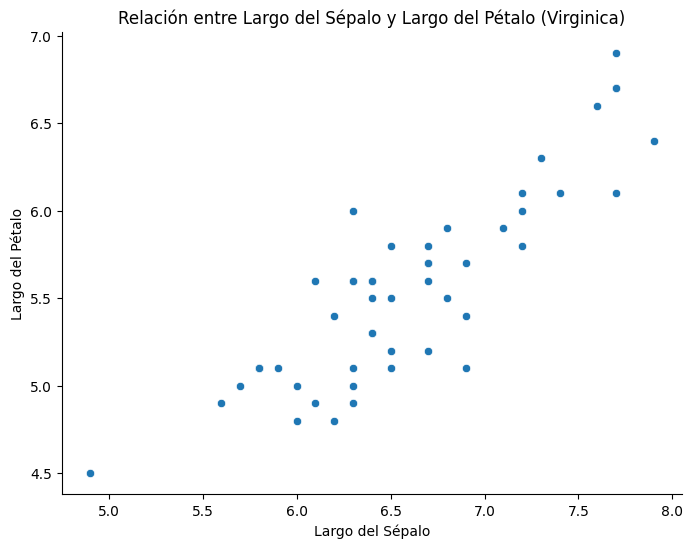

In [34]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="sepal_length", y="petal_length", data=virginica)
plt.title("Relación entre Largo del Sépalo y Largo del Pétalo (Virginica)")
plt.xlabel("Largo del Sépalo")
plt.ylabel("Largo del Pétalo")
sns.despine()
plt.show()

# correlación

In [35]:
correlacion = virginica["sepal_length"].corr(virginica["petal_length"])
print(f"Correlación entre sepal_length y petal_length: {correlacion:.2f}")

Correlación entre sepal_length y petal_length: 0.86


# Paso 3. Estimación del modelo de regresión lineal simple

In [36]:
modelo = smf.ols("petal_length ~ sepal_length", data=virginica).fit()
print("Resumen del modelo:")
print(modelo.summary())

Resumen del modelo:
                            OLS Regression Results                            
Dep. Variable:           petal_length   R-squared:                       0.747
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     141.6
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           6.30e-16
Time:                        17:50:31   Log-Likelihood:                -6.3742
No. Observations:                  50   AIC:                             16.75
Df Residuals:                      48   BIC:                             20.57
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.6105     

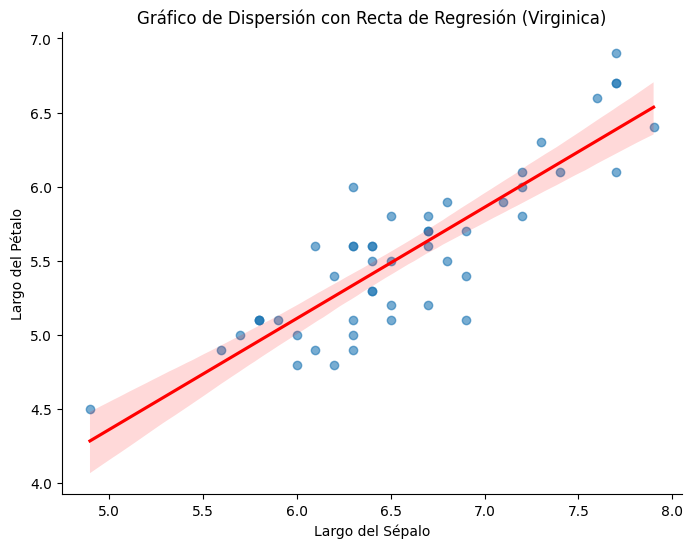

In [37]:
plt.figure(figsize=(8, 6))
sns.regplot(x='sepal_length', y='petal_length', data=virginica,
            scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Gráfico de Dispersión con Recta de Regresión (Virginica)')
plt.xlabel('Largo del Sépalo')
plt.ylabel('Largo del Pétalo')
sns.despine()
plt.show()

# Paso 4. Inferencias

In [38]:
# Pruebas de hipótesis (disponibles en el resumen del modelo estimado)
print("Resumen del modelo:")
print(modelo.summary())

Resumen del modelo:
                            OLS Regression Results                            
Dep. Variable:           petal_length   R-squared:                       0.747
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     141.6
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           6.30e-16
Time:                        17:50:32   Log-Likelihood:                -6.3742
No. Observations:                  50   AIC:                             16.75
Df Residuals:                      48   BIC:                             20.57
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.6105     

# Intervalo de confianza para beta1 (pendiente)

In [39]:
conf_interval_beta1 = modelo.conf_int(alpha=0.05)
print("Intervalo de confianza al 95% para los coeficientes:")
print(conf_interval_beta1.loc['sepal_length'])

Intervalo de confianza al 95% para los coeficientes:
0    0.623358
1    0.876803
Name: sepal_length, dtype: float64


# Intervalo de confianza para la media de y cuando x=6

In [40]:
nueva_data_conf = pd.DataFrame({'sepal_length': [6]})
prediccion_media = modelo.get_prediction(nueva_data_conf)
intervalo_conf_media = prediccion_media.summary_frame(alpha=0.05)
print("Intervalo de confianza al 95% para el largo del pétalo esperado (media) cuando el largo del sépalo es 6 cm:")
print(intervalo_conf_media[['mean', 'mean_ci_lower', 'mean_ci_upper']])

Intervalo de confianza al 95% para el largo del pétalo esperado (media) cuando el largo del sépalo es 6 cm:
       mean  mean_ci_lower  mean_ci_upper
0  5.110953       5.001795        5.22011


# Intervalo de predicción para una nueva observación y0 cuando x=6

In [41]:
nueva_data_pred = pd.DataFrame({'sepal_length': [6]})
prediccion_obs = modelo.get_prediction(nueva_data_pred)
intervalo_pred_obs = prediccion_obs.summary_frame(alpha=0.05)
print("Intervalo de predicción al 95% para el largo del pétalo de una nueva virginica cuando el largo del sépalo es 6 cm:")
print(intervalo_pred_obs[['mean', 'obs_ci_lower', 'obs_ci_upper']])

Intervalo de predicción al 95% para el largo del pétalo de una nueva virginica cuando el largo del sépalo es 6 cm:
       mean  obs_ci_lower  obs_ci_upper
0  5.110953      4.536426      5.685479
